In [1]:
from langgraph.graph import StateGraph,START,END,add_messages
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict,List,Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [3]:
loader1 = PyPDFLoader('Documents\Company_Policies.pdf')
loader2 = PyPDFLoader('Documents\Company_Profile.pdf')
loader3 = PyPDFLoader('Documents\Product_and_Pricing.pdf')

docs = loader1.load() + loader2.load() + loader3.load()

len(docs)

8

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size = 600,
    chunk_overlap = 150
)

chunks = splitter.split_documents(docs)

len(chunks)

16

In [5]:
embedding = OpenAIEmbeddings(model="text-embedding-3-large")

vector_store = FAISS.from_documents(
    embedding=embedding,
    documents=chunks
)

retriever = vector_store.as_retriever(
    search_type = 'mmr',
    search_kwargs = {'k':4}
)

In [6]:
class RagState(TypedDict):

    question : str
    need_retrieval : bool
    document : List[Document]
    answer : str

In [7]:
# decide_retrieval

class RetrievalDecision(BaseModel):

    should_retrieve : bool = Field(...,description="True if external documents are needed to answer reliably, else False.")

template = ChatPromptTemplate([
    ('system',"You decide whether retrieval is needed.\n"
        "Return JSON that matches this schema:\n"
        '{"should_retrieve": boolean}\n\n'
        "Rules:\n"
        "- should_retrieve=True if the answer might depend on factual information, statistics, recent info, documents, or citations.\n"
        "- should_retrieve=False only if the question can be answered with general knowledge or reasoning.\n"
        "- If there is ANY chance external information is needed, choose True."),
    ('human',"Question : {question}")
        ],
        input_variables = ['question']
        )

model_with_structure = model.with_structured_output(RetrievalDecision)

def decide_retrieval(state:RagState)->dict:

    question = state['question']

    chain = template | model_with_structure

    decision : RetrievalDecision = chain.invoke({'question':question})

    print("decide_retrieval : ",decision)

    return {'need_retrieval':decision.should_retrieve}

In [8]:
# generate_direct

template = ChatPromptTemplate([
    ('system',"Answer the question using your model parametric knowledge.\n"
            "Do NOT assume access to external documents.\n"),
    ('human',"Question : {question}")
],
input_variables = ['question']
)

def generate_direct(state:RagState)->dict:

    question = state['question']

    chain = template | model

    response = chain.invoke({'question':question})

    print("generate_direct : ",response)

    return {'answer' : response.content}

In [9]:
def retrieve(state:RagState)->dict:
    
    question = state['question']

    response = retriever.invoke(question)

    print("retrieve : ",response)

    return {'document':response}

In [10]:
def route_decision(state : RagState)->Literal['generate_direct','retrieve']:

    need_retrieval = state['need_retrieval']

    if need_retrieval:
        return 'retrieve'
    else:
        return 'generate_direct'

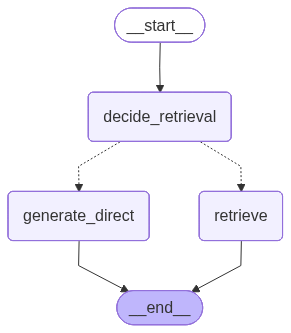

In [11]:
graph = StateGraph(RagState)

graph.add_node('decide_retrieval',decide_retrieval)
graph.add_node('generate_direct',generate_direct)
graph.add_node('retrieve',retrieve)

graph.add_edge(START,'decide_retrieval')
graph.add_conditional_edges('decide_retrieval',route_decision,{'generate_direct':'generate_direct','retrieve':'retrieve'})
graph.add_edge('generate_direct',END)
graph.add_edge('retrieve',END)

chatbot = graph.compile()

chatbot

In [17]:
response = chatbot.invoke({'question':'What is Machine Learning?'})

print(response)

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RetrievalDecision(should_retrieve=False), input_type=RetrievalDecision])
  return self.__pydantic_serializer__.to_python(


decide_retrieval :  should_retrieve=False
generate_direct :  content='Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit programming. Instead of being programmed with specific instructions, machine learning systems learn from data, identifying patterns and making decisions based on that data.\n\nThere are several key components and concepts in machine learning:\n\n1. **Data**: Machine learning relies on large amounts of data to train models. This data can be structured (like databases) or unstructured (like images or text).\n\n2. **Algorithms**: These are the mathematical models and procedures that process the data. Common algorithms include decision trees, neural networks, support vector machines, and clustering algorithms.\n\n3. **Training**: The process of feeding data into a machine learning model so it can learn from it. During training, the m

In [ ]:
# if retrieval == True

print(response['question'])
print('*'*100)
print(response['need_retrieval'])
print('*'*100)
print(response['document'])

What is Machine Learning?
****************************************************************************************************
False
****************************************************************************************************
****************************************************************************************************
Machine Learning (ML) is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit programming. Instead of being programmed with specific instructions, machine learning systems learn from data, identifying patterns and making decisions based on that data.

There are several key components and concepts in machine learning:

1. **Data**: Machine learning relies on large amounts of data to train models. This data can be structured (like databases) or unstructured (like images or text).

2. **Algorithms**: These are the mathematical models and procedures 

In [ ]:
# if generated direct
print(response['question'])
print('*'*100)
print(response['need_retrieval'])
print('*'*100)
print(response['answer'])

KeyError: 'document'